<div style="background: linear-gradient(135deg, #1b4332 0%, #2d6a4f 40%, #40916c 70%, #52b788 100%); padding: 44px; border-radius: 18px; color: white; text-align: center; margin-bottom: 24px; box-shadow: 0 8px 32px rgba(0,0,0,0.18);">
  <h1 style="font-size: 2.4em; margin-bottom: 6px; letter-spacing: 2px;">🌱 SmartRoot</h1>
  <p style="font-size: 1.05em; opacity: 0.9; margin-bottom: 18px;">Sistema portátil de bajo costo para estimación del potencial mátrico del suelo<br>mediante resistividad eléctrica y aprendizaje automático</p>
  <hr style="border-color: rgba(255,255,255,0.35); margin: 16px 0;">
  <h2 style="font-weight: 400; font-size: 1.4em;">📊 Notebook 05 — Tablero de Control Interactivo</h2>
  <p style="opacity: 0.8; font-size: 0.95em;">Dashboard · KPIs · Visualizaciones · Diagrama de flujo · Prototipo UI</p>
  <p style="opacity: 0.65; font-size: 0.85em; margin-top: 10px;">Fundamentos de Programación Científica · Maestría en Automatización y Control Industrial · 2026-1</p>
</div>

---

## ¿Qué construimos en este notebook?

Este es el notebook final del proyecto SmartRoot. Integra **todos los resultados** de los cuatro notebooks anteriores en un **tablero de control profesional e interactivo**.

El tablero está diseñado para dos audiencias:
- **Técnica** (agrónomo, investigador): gráficos detallados, estadísticas, correlaciones, simulación.
- **Ejecutiva** (agricultor, gerente): semáforo de riego, indicadores clave, recomendación clara.

### Elementos del tablero

| Elemento | Descripción | Requisito |
|---|---|---|
| 🃏 Tarjetas KPI | 3 indicadores con semáforo interactivo | Tabla de indicadores |
| 📈 Gráfico de líneas | Serie temporal ψ + lluvia + temperatura | Gráfico de línea |
| 📊 Gráfico de barras | KPIs mensuales con colores semáforo | Gráfico de barras |
| 📉 Histograma | Distribución de ψ + resultado Monte Carlo | Histograma |
| 🗺️ Mapa de calor | Estado hídrico espacial de la parcela | Captura de interfaz |
| 🔄 Diagrama de flujo | Flujo completo del sistema SmartRoot | Diagrama de flujo |
| 🎛️ Interactividad | Selector de período, umbral de riego ajustable | Dashboard interactivo |
| 📋 Tabla de datos | Dataset limpio completo exportable | Tabla de datos |

In [2]:
# Instalar librerías interactivas
!pip install -q plotly kaleido

In [4]:
# ============================================================
# SMARTROOT — Celda de inicio (ejecutar siempre primero)
# ============================================================

from google.colab import drive
import sys, os

drive.mount('/content/drive')

BASE      = '/content/drive/MyDrive/POSGRADO/2026-1/FUNDAMENTOS DE PROGRAMACIÓN CIENTÍFICA/CLASES/PROYECTO_FINAL'
DATA_PROC = f'{BASE}/data/processed'
FIGS      = f'{BASE}/outputs/figuras'
TABS      = f'{BASE}/outputs/tablas'

sys.path.insert(0, f'{BASE}/src')

# ============================================================
# LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe

from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

import plotly
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import ipywidgets as widgets

from IPython.display import display, HTML, clear_output

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ============================================================
# PALETA DE COLORES DEL PROYECTO
# ============================================================

C = dict(
    verde='#40916c',
    verde_claro='#95d5b2',
    verde_osc='#1b4332',

    amarillo='#f4a261',
    amarillo_claro='#ffe8d6',

    rojo='#e63946',
    rojo_claro='#ffd6d8',

    azul='#457b9d',
    azul_claro='#a8dadc',
    azul_osc='#0d3b66',

    morado='#6a0dad',
    gris='#6c757d',
    fondo='#f8faf9'
)

# ============================================================
# CONFIGURACIÓN DE GRÁFICAS
# ============================================================

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

# ============================================================
# CARGAR DATASET
# ============================================================

df = pd.read_csv(
    f'{DATA_PROC}/dataset_corregido.csv',
    index_col=0,
    parse_dates=True
)

# ============================================================
# MENSAJES DE VALIDACIÓN
# ============================================================

print(f'✅ Entorno listo. {len(df):,} registros cargados.')
print(f'   Plotly: {plotly.__version__}  |  ipywidgets: {widgets.__version__}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Entorno listo. 2,494 registros cargados.
   Plotly: 5.24.1  |  ipywidgets: 7.7.1


---
## Sección 1 — Preparación de datos del tablero

In [5]:
# ── Preparar todos los datos que necesita el tablero ─────────────────────

# Serie de tiempo cada 6 horas (fluida para gráficos)
df_6h = df.resample('6h').mean().dropna(subset=['psi_ref_hpa'])

# Clasificación hídrica de cada registro
def clasificar_estado(psi):
    if   psi <= 100: return 'Húmedo'
    elif psi <= 300: return 'Óptimo'
    elif psi <= 400: return 'Seco'
    else:            return 'Crítico'

df['estado_hidrico'] = df['psi_ref_hpa'].apply(clasificar_estado)
df_6h['estado_hidrico'] = df_6h['psi_ref_hpa'].apply(clasificar_estado)

# KPIs globales (del NB02)
kpi1_val = round(df['psi_ref_hpa'].mean(), 1)
mask_pos  = df['psi_ref_hpa'] > 0
kpi2_val  = round((abs(df.loc[mask_pos,'psi_ref_hpa'] - df.loc[mask_pos,'psi_gypsum_hpa']) /
                   df.loc[mask_pos,'psi_ref_hpa']).mean() * 100, 1)
kpi3_val  = round(((df['psi_ref_hpa'] > 100) & (df['psi_ref_hpa'] <= 300)).mean() * 100, 1)
r_gypsum  = df['psi_ref_hpa'].corr(df['psi_gypsum_hpa'])

# Resumen mensual (del NB02)
meses = {5:'Mayo 2016', 6:'Junio 2016', 7:'Julio 2016'}
resumen_mensual = []
for m, nombre in meses.items():
    sub = df[df.index.month == m]['psi_ref_hpa']
    resumen_mensual.append({
        'Mes': nombre, 'ψ promedio (hPa)': round(sub.mean(),1),
        'P(seco) %': round((sub > 300).mean()*100, 1),
        'N registros': len(sub),
        'Estado': '🟡 MONITOREAR' if sub.mean() > 250 else '🟢 VERDE'
    })
df_mensual = pd.DataFrame(resumen_mensual)

# Monte Carlo — 10.000 iteraciones para el período completo
MU_SESGO = -8.2; SIGMA = 26.7; UMBRAL = 300; N_MC = 10_000
psi_real_mc = np.random.normal(kpi1_val, df['psi_ref_hpa'].std(), N_MC)
ruido_mc    = np.random.normal(MU_SESGO, SIGMA, N_MC)
psi_mc      = psi_real_mc + ruido_mc
p_riego_mc  = round((psi_mc > UMBRAL).mean() * 100, 1)
ic95_low    = round(np.percentile(psi_mc, 2.5), 1)
ic95_high   = round(np.percentile(psi_mc, 97.5), 1)

print('✅ Datos del tablero preparados:')
print(f'   KPI1 ψ prom   : {kpi1_val} hPa  🟢')
print(f'   KPI2 MAPE      : {kpi2_val} %    🟢')
print(f'   KPI3 T_óptima  : {kpi3_val} %    🟢')
print(f'   r(Gypsum,ψ)    : {r_gypsum:.3f}')
print(f'   P(riego) MC    : {p_riego_mc}%  IC95: [{ic95_low}, {ic95_high}] hPa')
print(f'   Serie 6h       : {len(df_6h)} puntos')

✅ Datos del tablero preparados:
   KPI1 ψ prom   : 195.6 hPa  🟢
   KPI2 MAPE      : 13.3 %    🟢
   KPI3 T_óptima  : 74.5 %    🟢
   r(Gypsum,ψ)    : 0.949
   P(riego) MC    : 10.4%  IC95: [12.7, 359.3] hPa
   Serie 6h       : 209 puntos


---
## Sección 2 — Tarjetas de KPI interactivas

Las tarjetas muestran los tres indicadores de desempeño del NB02 en formato visual de semáforo, como aparecerían en la aplicación móvil de SmartRoot.

In [6]:
# ── Tarjetas KPI con HTML/CSS interactivo ─────────────────────────────────
# Renderizamos un panel HTML con las tarjetas — esto simula la interfaz
# móvil que vería el agricultor en la aplicación SmartRoot.

def render_kpi_cards(kpi1, kpi2, kpi3, p_mc):
    """Genera y muestra el panel HTML de tarjetas KPI interactivas."""

    s1 = ('🟢','#40916c','#d8f3dc') if kpi1 <= 250 else ('🟡','#f4a261','#fff3e4') if kpi1 <= 320 else ('🔴','#e63946','#ffe0e3')
    s2 = ('🟢','#40916c','#d8f3dc') if kpi2 <= 20  else ('🟡','#f4a261','#fff3e4') if kpi2 <= 35  else ('🔴','#e63946','#ffe0e3')
    s3 = ('🟢','#40916c','#d8f3dc') if kpi3 >= 70  else ('🟡','#f4a261','#fff3e4') if kpi3 >= 50  else ('🔴','#e63946','#ffe0e3')
    s4 = ('💧','#457b9d','#e3f2fd') if p_mc < 20  else ('🟡','#f4a261','#fff3e4') if p_mc < 50  else ('🔴','#e63946','#ffe0e3')

    cards = [
        (s1, 'ψ Promedio', f'{kpi1} hPa',   'Media de todos los\nregistros del período', 'Meta: ≤ 250 hPa',   'KPI 1'),
        (s2, 'Error MAPE',  f'{kpi2} %',     'Error Gypsum vs\nTensiómetro referencia', 'Meta: ≤ 20%',        'KPI 2'),
        (s3, 'Zona Óptima', f'{kpi3} %',     '% tiempo en rango\n100–300 hPa',           'Meta: ≥ 70%',        'KPI 3'),
        (s4, 'P(Riego) MC', f'{p_mc} %',     'Probabilidad de riego\n(Monte Carlo 10k iter)', 'Umbral: 50%',  'MC'),
    ]

    html_cards = ''.join(f"""
    <div style="background:{c[2]};border:2.5px solid {c[1]};border-radius:16px;
                padding:22px 18px;text-align:center;min-width:160px;flex:1;
                box-shadow:0 4px 16px rgba(0,0,0,0.08);transition:transform 0.2s;
                font-family:'Segoe UI',Arial,sans-serif;">
      <div style="font-size:11px;color:#666;font-weight:600;letter-spacing:1px;margin-bottom:6px;">{badge}</div>
      <div style="font-size:2.8em;margin:4px 0;">{em}</div>
      <div style="font-size:13px;font-weight:700;color:#333;margin-bottom:4px;">{title}</div>
      <div style="font-size:2em;font-weight:900;color:{c[1]};margin:8px 0;">{val}</div>
      <div style="font-size:10px;color:#888;white-space:pre-line;margin-bottom:8px;">{desc}</div>
      <div style="background:{c[1]};color:white;border-radius:20px;padding:4px 12px;
                  font-size:10px;font-weight:700;display:inline-block;">{meta}</div>
    </div>
    """ for (c, title, val, desc, meta, badge), em in [(card, card[0][0]) for card in cards])

    html_cards = ''.join(f"""
    <div style="background:{info[0][2]};border:2.5px solid {info[0][1]};border-radius:16px;
                padding:22px 18px;text-align:center;min-width:160px;flex:1;
                box-shadow:0 4px 16px rgba(0,0,0,0.08);
                font-family:'Segoe UI',Arial,sans-serif;">
      <div style="font-size:10px;color:#777;font-weight:700;letter-spacing:1.5px;text-transform:uppercase;margin-bottom:6px;">{info[5]}</div>
      <div style="font-size:2.6em;margin:6px 0;">{info[0][0]}</div>
      <div style="font-size:13px;font-weight:700;color:#333;margin-bottom:6px;">{info[1]}</div>
      <div style="font-size:2.2em;font-weight:900;color:{info[0][1]};margin:8px 0 10px;">{info[2]}</div>
      <div style="font-size:10px;color:#888;white-space:pre-line;line-height:1.5;margin-bottom:10px;">{info[3]}</div>
      <div style="background:{info[0][1]};color:white;border-radius:20px;padding:5px 14px;
                  font-size:10px;font-weight:700;display:inline-block;">{info[4]}</div>
    </div>
    """ for info in cards)

    display(HTML(f"""
    <div style="background:linear-gradient(135deg,#1b4332,#2d6a4f,#40916c);
                padding:20px 24px 12px;border-radius:18px;margin-bottom:16px;">
      <h2 style="color:white;margin:0 0 4px;font-family:'Segoe UI',Arial;
                 font-size:1.4em;letter-spacing:1px;">🌱 SmartRoot — Panel de Control</h2>
      <p style="color:rgba(255,255,255,0.75);margin:0;font-size:12px;font-family:'Segoe UI';">Parcela JKI · Dataset Jackisch et al. (2018) · Mayo–Julio 2016 · 2.494 registros</p>
    </div>
    <div style="display:flex;gap:14px;flex-wrap:wrap;margin-bottom:20px;">
      {html_cards}
    </div>
    """))

render_kpi_cards(kpi1_val, kpi2_val, kpi3_val, p_riego_mc)

---
## Sección 3 — Tablero interactivo Plotly (selector de período)

Gráficos interactivos con Plotly: zoom, hover, selección de período y comparación de sensores en tiempo real.

In [7]:
# ── Dashboard interactivo con Plotly ──────────────────────────────────────
# 4 paneles en un solo gráfico interactivo con selector de rango de fechas

fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=True,
    row_heights=[0.38, 0.22, 0.22, 0.18],
    vertical_spacing=0.04,
    subplot_titles=[
        'Potencial mátrico ψ — Tensiómetro vs Gypsum (resistivo)',
        'Humedad volumétrica θ del suelo',
        'Temperatura del suelo',
        'Precipitación'
    ]
)

# ── Panel 1: ψ mátrico ──
fig.add_trace(go.Scatter(
    x=df_6h.index, y=df_6h['psi_ref_hpa'],
    name='ψ Tensiómetro (referencia)',
    line=dict(color='#457b9d', width=2),
    hovertemplate='<b>Tensiómetro</b><br>%{x}<br>ψ = %{y:.1f} hPa<extra></extra>'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df_6h.index, y=df_6h['psi_gypsum_hpa'],
    name='ψ Gypsum (resistivo)',
    line=dict(color='#e63946', width=1.5, dash='dot'),
    hovertemplate='<b>Gypsum</b><br>%{x}<br>ψ = %{y:.1f} hPa<extra></extra>'
), row=1, col=1)

# Banda zona óptima
fig.add_hrect(y0=100, y1=300, row=1, col=1,
              fillcolor='rgba(64,145,108,0.10)', line_width=0,
              annotation_text='Zona óptima', annotation_position='top right',
              annotation_font_size=10)
# Umbral de riego
fig.add_hline(y=300, row=1, col=1,
              line=dict(color='#f4a261', dash='dash', width=1.5),
              annotation_text='Umbral riego (300 hPa)', annotation_font_size=10)

# ── Panel 2: Humedad volumétrica ──
fig.add_trace(go.Scatter(
    x=df_6h.index, y=df_6h['theta_pct'],
    name='Humedad volumétrica θ',
    fill='tozeroy', fillcolor='rgba(64,145,108,0.15)',
    line=dict(color='#40916c', width=1.8),
    hovertemplate='<b>θ</b><br>%{x}<br>%{y:.2f} m³/m³×100<extra></extra>'
), row=2, col=1)

# ── Panel 3: Temperatura ──
fig.add_trace(go.Scatter(
    x=df_6h.index, y=df_6h['temp_c'],
    name='Temperatura suelo',
    fill='tozeroy', fillcolor='rgba(244,162,97,0.15)',
    line=dict(color='#f4a261', width=1.8),
    hovertemplate='<b>Temp</b><br>%{x}<br>%{y:.1f}°C<extra></extra>'
), row=3, col=1)

# ── Panel 4: Precipitación ──
fig.add_trace(go.Bar(
    x=df_6h.index, y=df_6h['precip_mm'],
    name='Precipitación',
    marker_color='#457b9d', opacity=0.7,
    hovertemplate='<b>Lluvia</b><br>%{x}<br>%{y:.2f} mm<extra></extra>'
), row=4, col=1)

# ── Layout general ────────────────────────────────────────────────────────
fig.update_layout(
    title=dict(
        text='🌱 SmartRoot — Serie Temporal Interactiva<br>'
             '<span style="font-size:12px;color:#666;">Parcela JKI · Jackisch et al. (2018) · '
             'Mayo–Julio 2016 — Usa el ratón para hacer zoom y navegar</span>',
        font=dict(size=16), x=0.5, xanchor='center'
    ),
    height=720,
    plot_bgcolor='#fafbfa',
    paper_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1,
                bgcolor='rgba(255,255,255,0.8)', bordercolor='#ddd', borderwidth=1),
    hovermode='x unified',
    font=dict(family='Segoe UI, Arial', size=11),
    # Selector de rango interactivo
    xaxis4=dict(
        rangeselector=dict(
            buttons=[
                dict(count=7,  label='1 sem', step='day',  stepmode='backward'),
                dict(count=14, label='2 sem', step='day',  stepmode='backward'),
                dict(count=1,  label='1 mes', step='month',stepmode='backward'),
                dict(step='all',label='Todo'),
            ],
            bgcolor='#f0f4f0', activecolor='#40916c',
            font=dict(size=10),
        ),
        rangeslider=dict(visible=True, thickness=0.04),
        type='date'
    ),
)

# Ejes Y con etiquetas
fig.update_yaxes(title_text='ψ (hPa)', autorange='reversed', row=1, col=1,
                 gridcolor='#eee')
fig.update_yaxes(title_text='θ (%)',   row=2, col=1, gridcolor='#eee')
fig.update_yaxes(title_text='T (°C)',  row=3, col=1, gridcolor='#eee')
fig.update_yaxes(title_text='mm',      row=4, col=1, gridcolor='#eee')

fig.show()

# Guardar versión estática
try:
    fig.write_image(f'{FIGS}/05_serie_interactiva.png', scale=1.5)
    print('💾 PNG guardado: outputs/figuras/05_serie_interactiva.png')
except:
    print('💡 Para exportar PNG instala: pip install kaleido')

# Guardar HTML interactivo
fig.write_html(f'{FIGS}/05_serie_interactiva.html')
print('💾 HTML interactivo: outputs/figuras/05_serie_interactiva.html')

💡 Para exportar PNG instala: pip install kaleido
💾 HTML interactivo: outputs/figuras/05_serie_interactiva.html


---
## Sección 4 — Widget interactivo: simulador de decisión de riego

Un widget con sliders que permite al agrónomo explorar cómo cambia la probabilidad de riego al variar el umbral de decisión o el estado del suelo.

In [8]:
# ── Widget interactivo — Simulador de decisión de riego ───────────────────

# Sliders de control
slider_psi = widgets.FloatSlider(
    value=195.6, min=50, max=450, step=5,
    description='ψ real (hPa):',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='480px'),
    readout_format='.0f'
)
slider_sigma = widgets.FloatSlider(
    value=26.7, min=5, max=80, step=2.5,
    description='σ ruido (hPa):',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='480px'),
    readout_format='.1f'
)
slider_umbral = widgets.IntSlider(
    value=300, min=150, max=500, step=10,
    description='Umbral riego (hPa):',
    style={'description_width': '130px'},
    layout=widgets.Layout(width='480px')
)
btn_simular = widgets.Button(
    description='🎲 Simular 10.000 iteraciones',
    button_style='success',
    layout=widgets.Layout(width='280px', height='38px')
)
output_widget = widgets.Output()

def simular_callback(btn):
    with output_widget:
        clear_output(wait=True)
        psi_real_w = slider_psi.value
        sigma_w    = slider_sigma.value
        umbral_w   = slider_umbral.value

        # Monte Carlo
        psi_sim = np.random.normal(psi_real_w, sigma_w * 1.5, 10_000)
        p_riego = (psi_sim > umbral_w).mean() * 100
        ic_low  = np.percentile(psi_sim, 2.5)
        ic_high = np.percentile(psi_sim, 97.5)

        # Recomendación
        if   p_riego < 20: rec, ec, bc = 'NO REGAR',      '💧', '#457b9d'
        elif p_riego < 50: rec, ec, bc = 'MONITOREAR',    '🟡', '#f4a261'
        elif p_riego < 75: rec, ec, bc = 'REGAR HOY',     '🟠', '#e76f51'
        else:              rec, ec, bc = 'RIEGO URGENTE', '🔴', '#e63946'

        # Gráfico
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
        fig.patch.set_facecolor('#fafbfa')
        fig.suptitle(f'SmartRoot — Simulación Monte Carlo  |  ψ_real={psi_real_w:.0f} hPa  '
                     f'σ={sigma_w:.1f} hPa  Umbral={umbral_w} hPa',
                     fontsize=12, fontweight='bold')

        # Histograma
        ax1.hist(psi_sim, bins=80, density=True, color=bc, alpha=0.65,
                 edgecolor='white', linewidth=0.3)
        x_r = np.linspace(psi_sim.min(), psi_sim.max(), 300)
        ax1.plot(x_r, stats.norm.pdf(x_r, psi_sim.mean(), psi_sim.std()),
                 color='navy', lw=2)
        ax1.axvline(umbral_w, color='#e63946', lw=2, linestyle='--',
                    label=f'Umbral: {umbral_w} hPa')
        ax1.axvline(ic_low,   color='gray', lw=1.2, linestyle=':')
        ax1.axvline(ic_high,  color='gray', lw=1.2, linestyle=':',
                    label=f'IC 95%: [{ic_low:.0f}, {ic_high:.0f}]')
        x_area = x_r[x_r > umbral_w]
        ax1.fill_between(x_area, stats.norm.pdf(x_area, psi_sim.mean(), psi_sim.std()),
                         alpha=0.3, color='#e63946',
                         label=f'P(riego) = {p_riego:.1f}%')
        ax1.set_xlabel('ψ simulado (hPa)'); ax1.set_ylabel('Densidad')
        ax1.set_title('Distribución Monte Carlo')
        ax1.legend(fontsize=9)

        # Medidor de probabilidad
        theta_gauge = np.linspace(0, np.pi, 300)
        ax2.axis('off')
        ax2.set_xlim(-1.2, 1.2); ax2.set_ylim(-0.3, 1.2)
        # Arco de fondo
        for pct, col in [(20,'#457b9d'),(30,'#f4a261'),(25,'#e76f51'),(25,'#e63946')]:
            pass
        # Arco coloreado por zonas
        zonas = [(0.20, '#457b9d'), (0.50, '#f4a261'), (0.75, '#e76f51'), (1.0, '#e63946')]
        prev = 0
        for lim, col in zonas:
            t = np.linspace(prev * np.pi, lim * np.pi, 100)
            ax2.fill_between(np.cos(t), np.sin(t)*0.7, np.sin(t)*1.0,
                             color=col, alpha=0.75)
            prev = lim
        # Aguja
        angle = (1 - p_riego/100) * np.pi
        ax2.annotate('', xy=(np.cos(angle)*0.85, np.sin(angle)*0.85),
                     xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color='#1b4332',
                                    lw=3, mutation_scale=20))
        ax2.text(0, -0.1, f'{p_riego:.1f}%', ha='center', va='center',
                 fontsize=28, fontweight='bold', color=bc)
        ax2.text(0, -0.25, f'{ec}  {rec}', ha='center', va='center',
                 fontsize=14, fontweight='bold', color=bc)
        ax2.text(-1.1, 0, '0%', ha='center', fontsize=9, color='#666')
        ax2.text(1.1, 0, '100%', ha='center', fontsize=9, color='#666')
        ax2.text(0, 1.1, 'P(riego)', ha='center', fontsize=11, fontweight='bold')
        ax2.set_title('Medidor de probabilidad de riego', pad=12)

        plt.tight_layout()
        plt.show()

btn_simular.on_click(simular_callback)

display(HTML('<div style="background:#f0f7f0;padding:16px;border-radius:12px;'
             'border:2px solid #40916c;margin-bottom:12px;">'
             '<b>🎛️ Simulador interactivo de decisión de riego</b><br>'
             '<span style="font-size:12px;color:#555;">Ajusta los parámetros con los sliders '
             'y presiona el botón para ver cómo cambia la recomendación de riego.</span></div>'))
display(widgets.VBox([
    slider_psi, slider_sigma, slider_umbral, btn_simular, output_widget
]))

# Ejecutar la simulación inicial
btn_simular.click()

---
## Sección 5 — Tablero estático integrado (matplotlib)

Versión estática de alta calidad del tablero completo — ideal para el informe y la presentación.

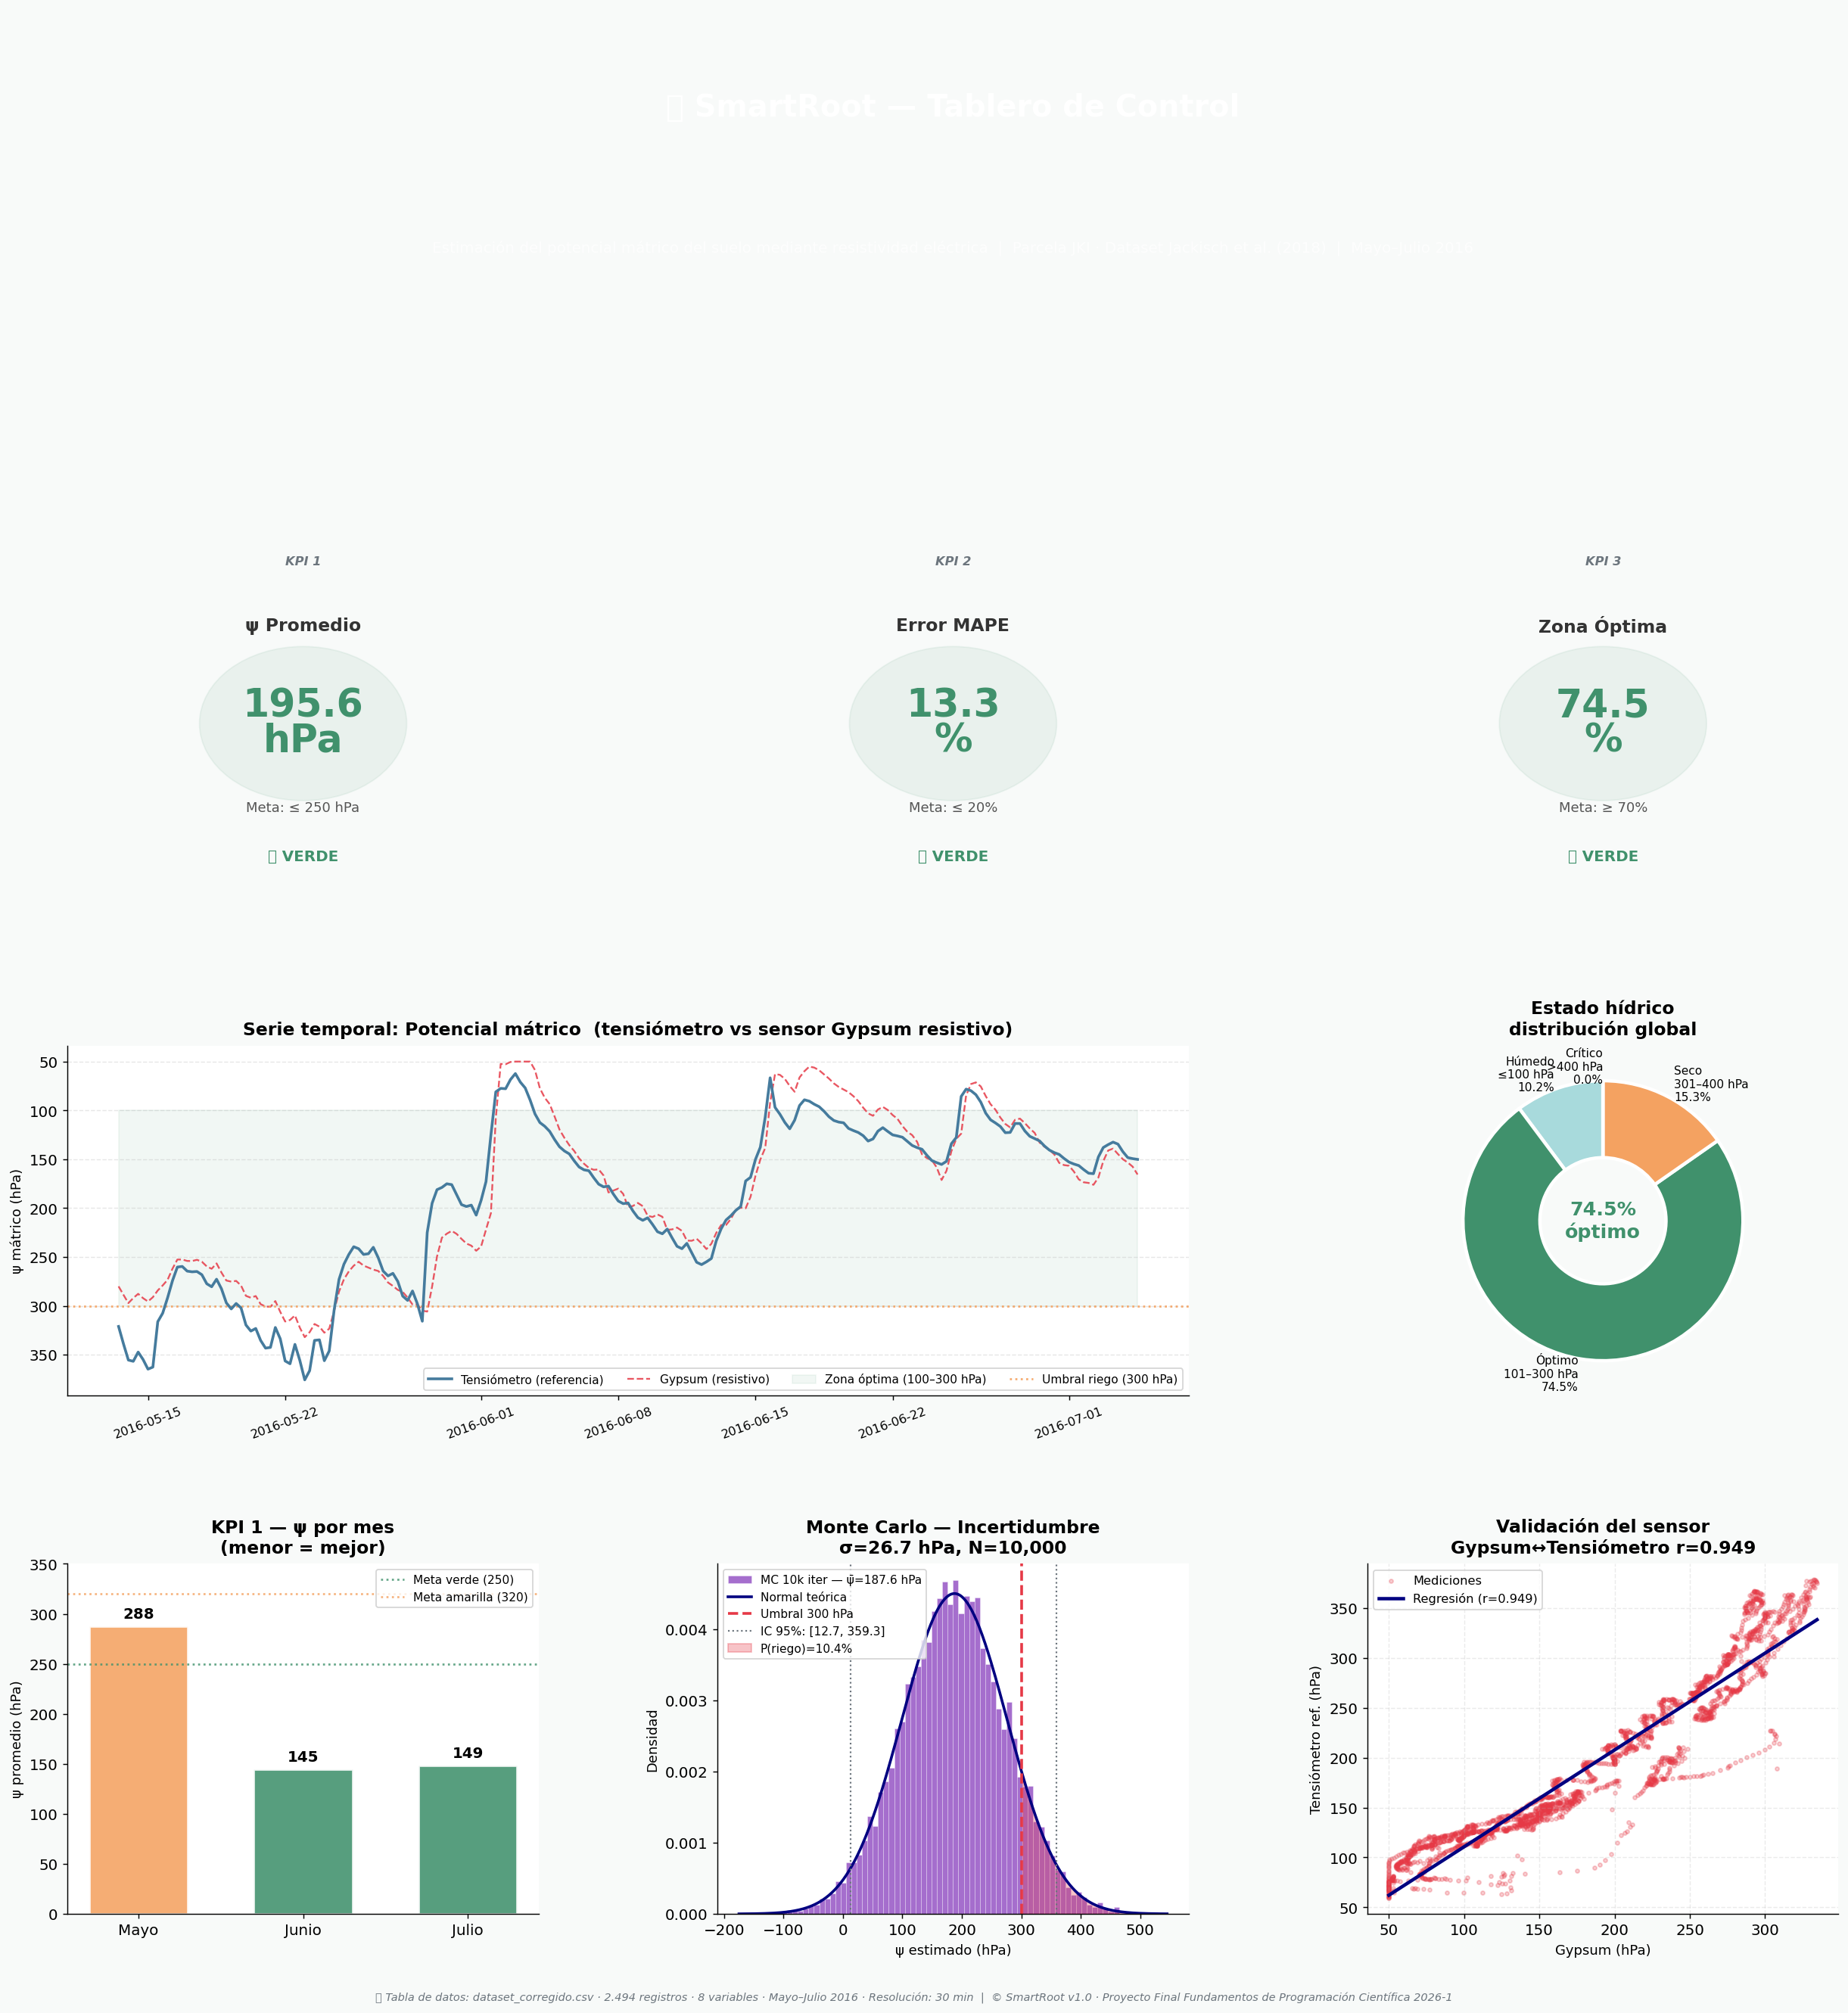

💾 Guardado: outputs/figuras/05_tablero_control_completo.png


In [10]:
# ─────────────────────────────────────────────────────────────
# TABLERO COMPLETO SMARTROOT
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 22), facecolor=C['fondo'])
fig.patch.set_facecolor(C['fondo'])

gs = gridspec.GridSpec(
    4, 3,
    figure=fig,
    hspace=0.48,
    wspace=0.38,
    top=0.93,
    bottom=0.05,
    left=0.07,
    right=0.97
)

# ─────────────────────────────────────────────────────────────
# ENCABEZADO
# ─────────────────────────────────────────────────────────────

ax_header = fig.add_subplot(gs[0, :])

ax_header.set_facecolor(C['verde_osc'])
ax_header.axis('off')

for spine in ax_header.spines.values():
    spine.set_visible(False)

ax_header.text(
    0.5, 0.72,
    '🌱 SmartRoot — Tablero de Control',
    ha='center',
    va='center',
    fontsize=22,
    fontweight='bold',
    color='white',
    transform=ax_header.transAxes
)

ax_header.text(
    0.5, 0.32,
    'Estimación del potencial mátrico del suelo mediante resistividad eléctrica  |  '
    'Parcela JKI · Dataset Jackisch et al. (2018)  |  Mayo–Julio 2016',
    ha='center',
    va='center',
    fontsize=11,
    color='white',
    alpha=0.8,
    transform=ax_header.transAxes
)

ax_header.set_xlim(0, 1)
ax_header.set_ylim(0, 1)

# ─────────────────────────────────────────────────────────────
# FILA 1 — KPI CARDS
# ─────────────────────────────────────────────────────────────

kpi_config = [
    ('KPI 1', 'ψ Promedio', f'{kpi1_val}\nhPa',
     C['verde'], '≤ 250 hPa', '🟢 VERDE', '195.6 < 250'),

    ('KPI 2', 'Error MAPE', f'{kpi2_val}\n%',
     C['verde'], '≤ 20%', '🟢 VERDE', '13.3% < 20%'),

    ('KPI 3', 'Zona Óptima', f'{kpi3_val}\n%',
     C['verde'], '≥ 70%', '🟢 VERDE', '74.5% > 70%'),
]

for i, (badge, nombre, valor, color, meta, estado, nota) in enumerate(kpi_config):

    ax_k = fig.add_subplot(gs[1, i])

    ax_k.set_facecolor('#ffffff')

    for sp in ax_k.spines.values():
        sp.set_color(color)
        sp.set_linewidth(2.5)

    ax_k.axis('off')

    ax_k.text(
        0.5, 0.92,
        badge,
        ha='center',
        va='top',
        fontsize=9,
        color=C['gris'],
        fontweight='bold',
        transform=ax_k.transAxes,
        style='italic'
    )

    ax_k.text(
        0.5, 0.72,
        nombre,
        ha='center',
        va='center',
        fontsize=13,
        fontweight='bold',
        color='#333',
        transform=ax_k.transAxes
    )

    ax_k.text(
        0.5, 0.44,
        valor,
        ha='center',
        va='center',
        fontsize=28,
        fontweight='black',
        color=color,
        transform=ax_k.transAxes,
        linespacing=0.9
    )

    ax_k.text(
        0.5, 0.20,
        f'Meta: {meta}',
        ha='center',
        va='center',
        fontsize=10,
        color='#555',
        transform=ax_k.transAxes
    )

    ax_k.text(
        0.5, 0.06,
        estado,
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        color=color,
        transform=ax_k.transAxes
    )

    circ = plt.Circle(
        (0.5, 0.44),
        0.22,
        transform=ax_k.transAxes,
        color=color,
        alpha=0.08,
        zorder=0
    )

    ax_k.add_patch(circ)

# ─────────────────────────────────────────────────────────────
# FILA 2 — SERIE TEMPORAL
# ─────────────────────────────────────────────────────────────

ax_serie = fig.add_subplot(gs[2, :2])

ax_serie.set_facecolor('#ffffff')

ax_serie.plot(
    df_6h.index,
    df_6h['psi_ref_hpa'],
    color=C['azul'],
    lw=2,
    label='Tensiómetro (referencia)',
    zorder=3
)

ax_serie.plot(
    df_6h.index,
    df_6h['psi_gypsum_hpa'],
    color=C['rojo'],
    lw=1.3,
    linestyle='--',
    label='Gypsum (resistivo)',
    alpha=0.85,
    zorder=2
)

ax_serie.fill_between(
    df_6h.index,
    100,
    300,
    alpha=0.07,
    color=C['verde'],
    label='Zona óptima (100–300 hPa)'
)

ax_serie.axhline(
    300,
    color=C['amarillo'],
    lw=1.5,
    linestyle=':',
    alpha=0.9,
    label='Umbral riego (300 hPa)'
)

ax_serie.set_ylabel('ψ mátrico (hPa)', fontsize=10)

ax_serie.set_title(
    'Serie temporal: Potencial mátrico  (tensiómetro vs sensor Gypsum resistivo)',
    pad=8
)

ax_serie.legend(fontsize=8.5, ncol=4, loc='lower right')

ax_serie.invert_yaxis()

ax_serie.tick_params(axis='x', rotation=20, labelsize=9)

ax_serie.grid(axis='y', alpha=0.3, linestyle='--')

# ─────────────────────────────────────────────────────────────
# FILA 2 — DONA ESTADO HÍDRICO
# ─────────────────────────────────────────────────────────────

ax_dona = fig.add_subplot(gs[2, 2])

ax_dona.set_facecolor('#ffffff')

vals_dona = [10.2, 74.5, 15.3, 0.0]

labels_dona = [
    'Húmedo\n≤100 hPa\n10.2%',
    'Óptimo\n101–300 hPa\n74.5%',
    'Seco\n301–400 hPa\n15.3%',
    'Crítico\n>400 hPa\n0.0%'
]

colores_dona = [
    C['azul_claro'],
    C['verde'],
    C['amarillo'],
    C['rojo']
]

wedges, texts = ax_dona.pie(
    vals_dona,
    labels=labels_dona,
    colors=colores_dona,
    startangle=90,
    wedgeprops=dict(
        width=0.55,
        edgecolor='white',
        linewidth=2.5
    )
)

for t in texts:
    t.set_fontsize(8.5)

ax_dona.text(
    0, 0,
    '74.5%\nóptimo',
    ha='center',
    va='center',
    fontsize=14,
    fontweight='bold',
    color=C['verde']
)

ax_dona.set_title(
    'Estado hídrico\ndistribución global',
    pad=8
)

# ─────────────────────────────────────────────────────────────
# FILA 3 — KPI MENSUAL
# ─────────────────────────────────────────────────────────────

ax_barras = fig.add_subplot(gs[3, 0])

ax_barras.set_facecolor('#ffffff')

meses_nombres = df_mensual['Mes'].str.replace(' 2016', '').tolist()

psi_vals_m = df_mensual['ψ promedio (hPa)'].tolist()

colores_barras = [
    C['amarillo'] if v > 250 else C['verde']
    for v in psi_vals_m
]

barras = ax_barras.bar(
    meses_nombres,
    psi_vals_m,
    color=colores_barras,
    alpha=0.88,
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

for b, v in zip(barras, psi_vals_m):

    ax_barras.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 5,
        f'{v:.0f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

ax_barras.axhline(
    250,
    color=C['verde'],
    lw=1.5,
    linestyle=':',
    alpha=0.8,
    label='Meta verde (250)'
)

ax_barras.axhline(
    320,
    color=C['amarillo'],
    lw=1.5,
    linestyle=':',
    alpha=0.8,
    label='Meta amarilla (320)'
)

ax_barras.set_ylabel('ψ promedio (hPa)', fontsize=10)

ax_barras.set_title(
    'KPI 1 — ψ por mes\n(menor = mejor)',
    pad=8
)

ax_barras.legend(fontsize=8.5)

ax_barras.set_ylim(0, 350)

# ─────────────────────────────────────────────────────────────
# FILA 3 — MONTE CARLO
# ─────────────────────────────────────────────────────────────

ax_mc = fig.add_subplot(gs[3, 1])

ax_mc.set_facecolor('#ffffff')

ax_mc.hist(
    psi_mc,
    bins=80,
    density=True,
    color=C['morado'],
    alpha=0.6,
    edgecolor='white',
    linewidth=0.3,
    label=f'MC 10k iter — ψ̄={np.mean(psi_mc):.1f} hPa'
)

x_mc = np.linspace(psi_mc.min(), psi_mc.max(), 300)

ax_mc.plot(
    x_mc,
    stats.norm.pdf(
        x_mc,
        np.mean(psi_mc),
        np.std(psi_mc)
    ),
    color='navy',
    lw=2,
    label='Normal teórica'
)

ax_mc.axvline(
    300,
    color=C['rojo'],
    lw=2,
    linestyle='--',
    label='Umbral 300 hPa'
)

ax_mc.axvline(
    ic95_low,
    color=C['gris'],
    lw=1.2,
    linestyle=':'
)

ax_mc.axvline(
    ic95_high,
    color=C['gris'],
    lw=1.2,
    linestyle=':',
    label=f'IC 95%: [{ic95_low}, {ic95_high}]'
)

x_area = x_mc[x_mc > 300]

ax_mc.fill_between(
    x_area,
    stats.norm.pdf(
        x_area,
        np.mean(psi_mc),
        np.std(psi_mc)
    ),
    alpha=0.3,
    color=C['rojo'],
    label=f'P(riego)={p_riego_mc}%'
)

ax_mc.set_xlabel('ψ estimado (hPa)', fontsize=10)

ax_mc.set_ylabel('Densidad', fontsize=10)

ax_mc.set_title(
    f'Monte Carlo — Incertidumbre\nσ={SIGMA:.1f} hPa, N={N_MC:,}',
    pad=8
)

ax_mc.legend(fontsize=8.5)

# ─────────────────────────────────────────────────────────────
# FILA 3 — CORRELACIÓN
# ─────────────────────────────────────────────────────────────

ax_corr = fig.add_subplot(gs[3, 2])

ax_corr.set_facecolor('#ffffff')

msk = df[['psi_ref_hpa', 'psi_gypsum_hpa']].dropna()

ax_corr.scatter(
    msk['psi_gypsum_hpa'],
    msk['psi_ref_hpa'],
    alpha=0.25,
    s=8,
    color=C['rojo'],
    label='Mediciones'
)

z = np.polyfit(
    msk['psi_gypsum_hpa'],
    msk['psi_ref_hpa'],
    1
)

x_line = np.linspace(
    msk['psi_gypsum_hpa'].min(),
    msk['psi_gypsum_hpa'].max(),
    100
)

ax_corr.plot(
    x_line,
    np.poly1d(z)(x_line),
    color='navy',
    lw=2.5,
    label=f'Regresión (r={r_gypsum:.3f})'
)

ax_corr.set_xlabel('Gypsum (hPa)', fontsize=10)

ax_corr.set_ylabel('Tensiómetro ref. (hPa)', fontsize=10)

ax_corr.set_title(
    f'Validación del sensor\nGypsum↔Tensiómetro r={r_gypsum:.3f}',
    pad=8
)

ax_corr.legend(fontsize=9)

ax_corr.grid(alpha=0.25, linestyle='--')

# ─────────────────────────────────────────────────────────────
# PIE DE FIGURA
# ─────────────────────────────────────────────────────────────

fig.text(
    0.5,
    0.01,
    '📋 Tabla de datos: dataset_corregido.csv · 2.494 registros · '
    '8 variables · Mayo–Julio 2016 · Resolución: 30 min  |  '
    '© SmartRoot v1.0 · Proyecto Final Fundamentos de Programación Científica 2026-1',
    ha='center',
    fontsize=8,
    color=C['gris'],
    style='italic'
)

# ─────────────────────────────────────────────────────────────
# GUARDAR Y MOSTRAR
# ─────────────────────────────────────────────────────────────

plt.savefig(
    f'{FIGS}/05_tablero_control_completo.png',
    bbox_inches='tight',
    dpi=160,
    facecolor=C['fondo']
)

plt.show()

print('💾 Guardado: outputs/figuras/05_tablero_control_completo.png')

---
## Sección 6 — Diagrama de flujo del sistema SmartRoot

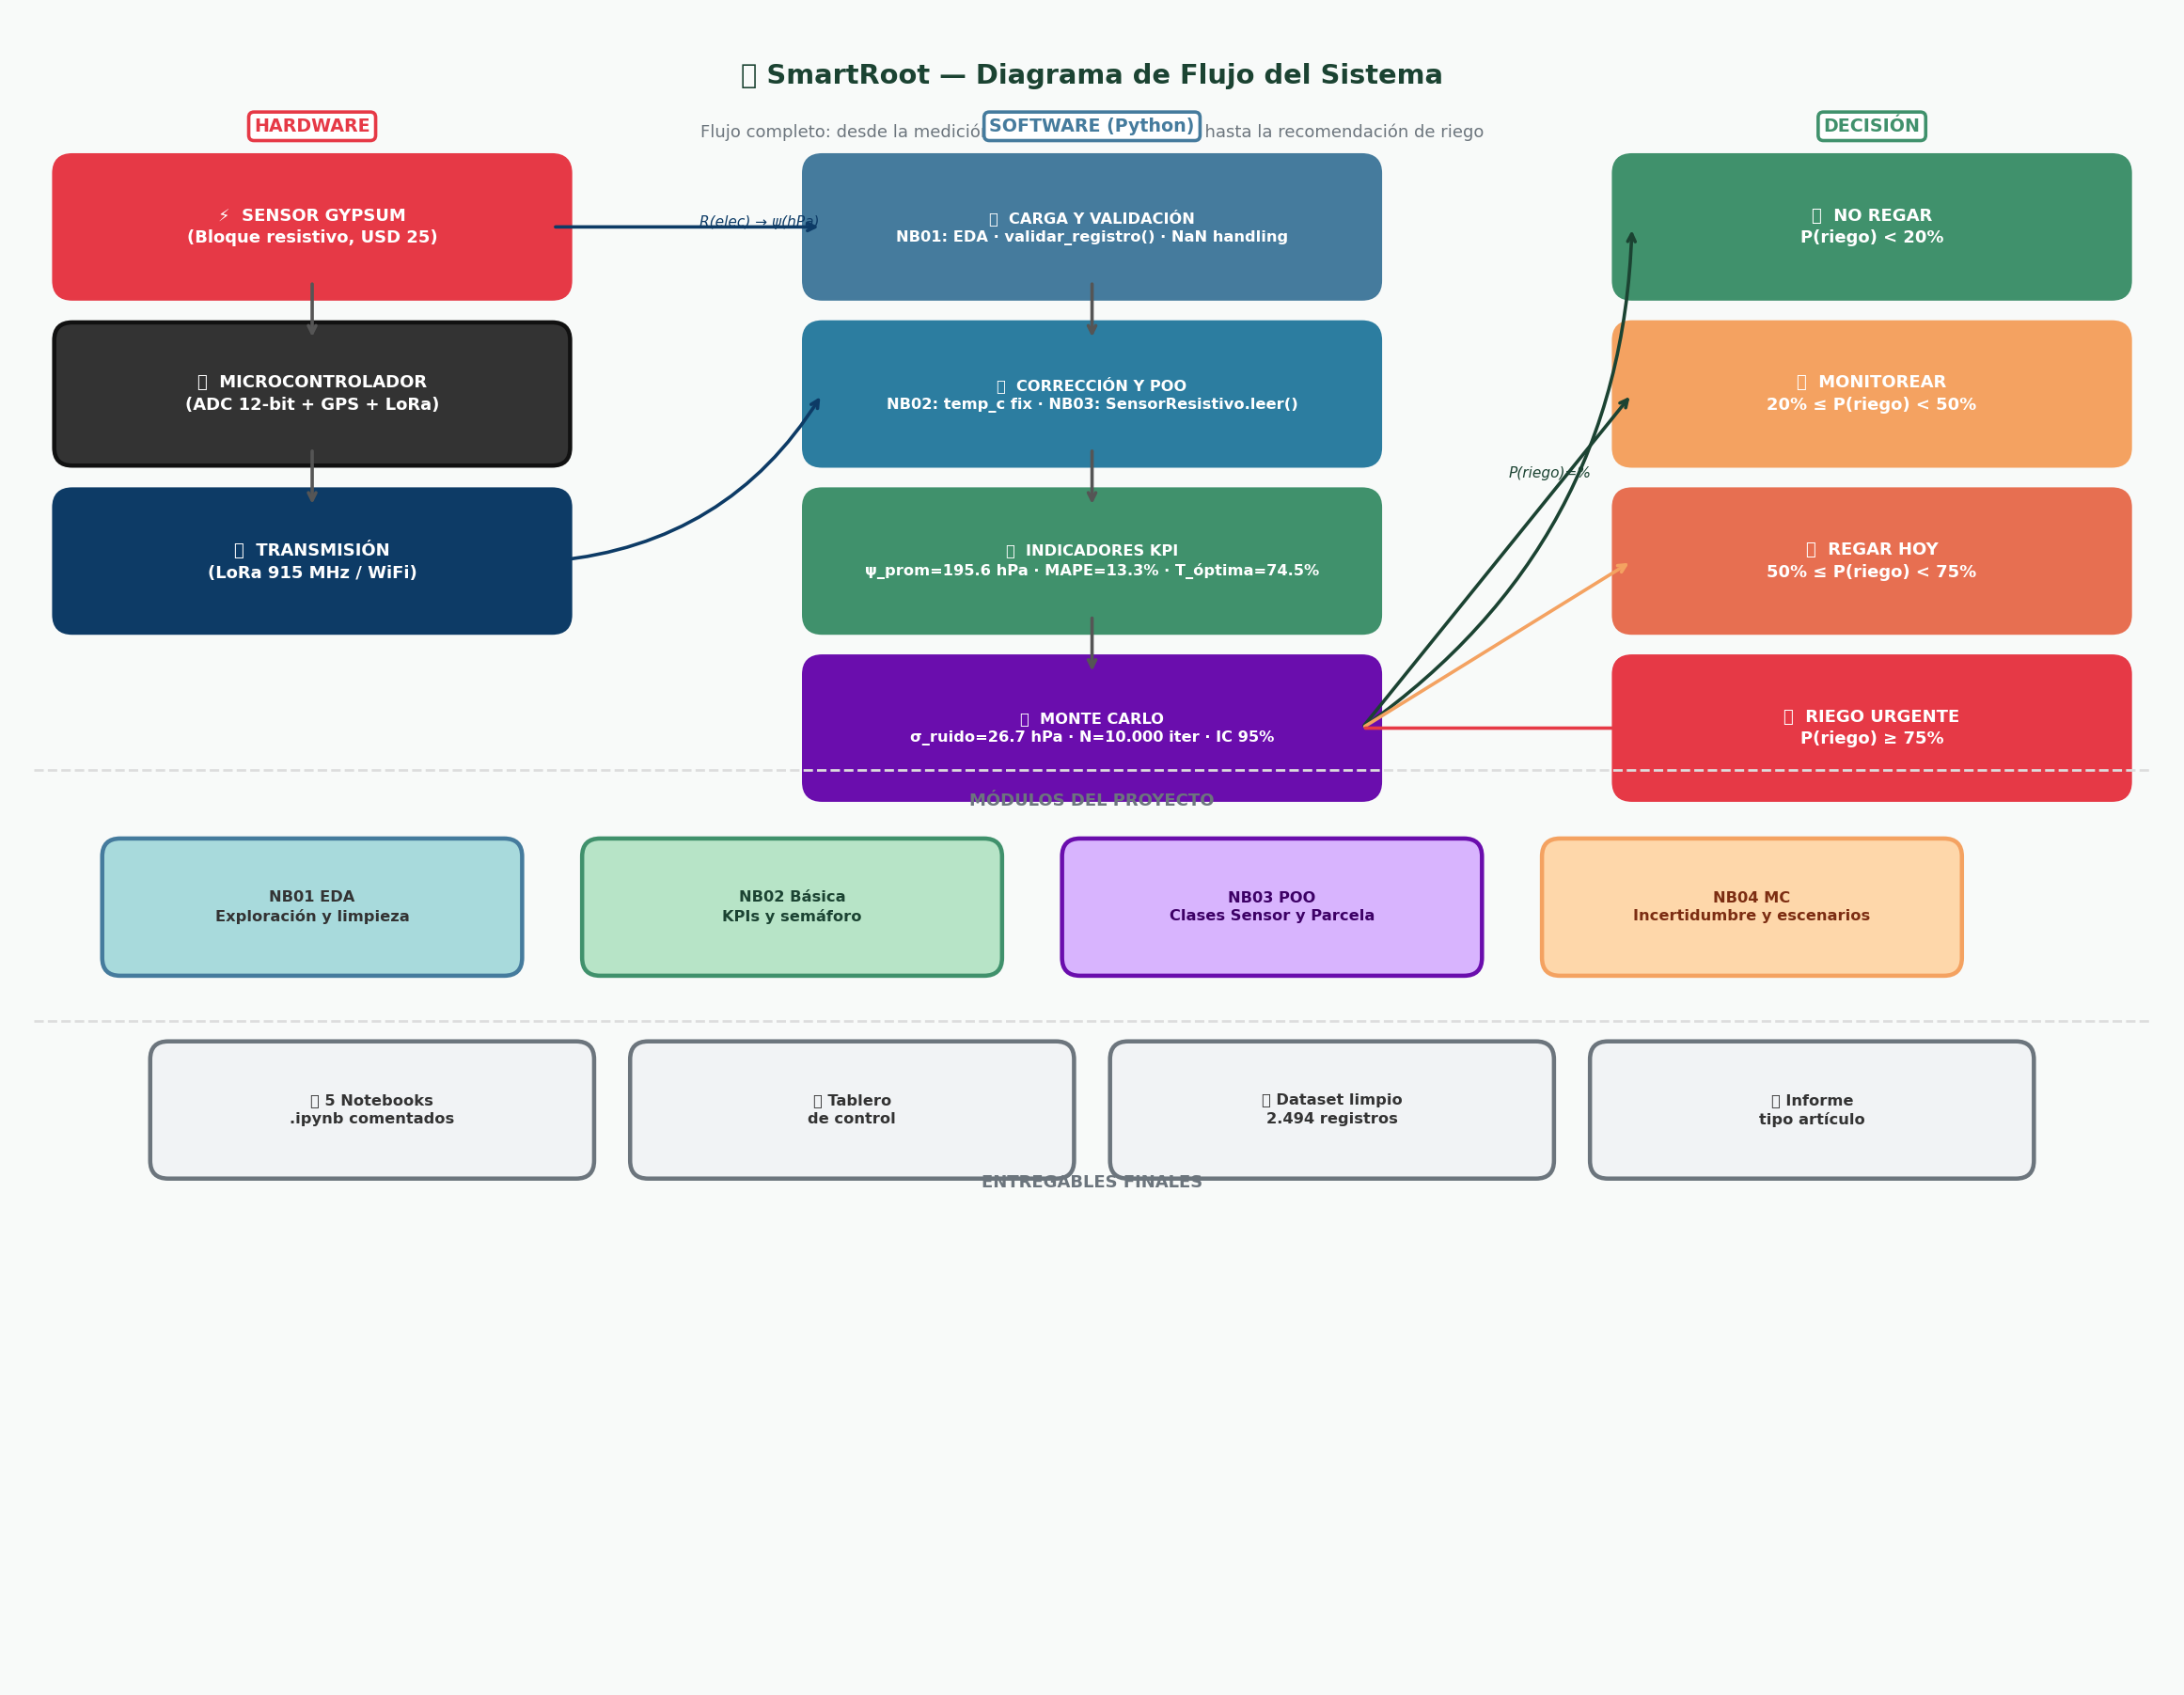

💾 Guardado: outputs/figuras/05_diagrama_flujo.png


In [11]:
# ── Diagrama de flujo completo del sistema SmartRoot ──────────────────────
fig, ax = plt.subplots(figsize=(18, 14), facecolor='#f8faf9')
ax.set_xlim(0, 18); ax.set_ylim(0, 14)
ax.axis('off')
fig.patch.set_facecolor('#f8faf9')

# ── Función auxiliar para dibujar cajas ───────────────────────────────────
def caja(ax, x, y, w, h, texto, color_fondo, color_borde,
          fontsize=9, texto_color='white', bold=True, radio=0.15):
    rect = FancyBboxPatch((x-w/2, y-h/2), w, h,
                           boxstyle=f'round,pad={radio}',
                           facecolor=color_fondo, edgecolor=color_borde,
                           linewidth=2.5, zorder=2)
    ax.add_patch(rect)
    ax.text(x, y, texto, ha='center', va='center',
            fontsize=fontsize, fontweight='bold' if bold else 'normal',
            color=texto_color, zorder=3, linespacing=1.4)

def flecha(ax, x1, y1, x2, y2, color='#555', label='', curva=False):
    if curva:
        ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2,
                                   connectionstyle='arc3,rad=0.25'))
    else:
        ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2))
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx+0.1, my, label, fontsize=8.5, color=color,
                style='italic', ha='left')

# ── TÍTULO ────────────────────────────────────────────────────────────────
ax.text(9, 13.4, '🌱 SmartRoot — Diagrama de Flujo del Sistema',
        ha='center', fontsize=16, fontweight='bold', color=C['verde_osc'])
ax.text(9, 12.95,
        'Flujo completo: desde la medición de resistividad eléctrica hasta la recomendación de riego',
        ha='center', fontsize=10, color=C['gris'])

# ── COLUMNA 1: HARDWARE (sensores físicos) ────────────────────────────────
caja(ax, 2.5, 12.2, 4.0, 0.9,
     '⚡  SENSOR GYPSUM\n(Bloque resistivo, USD 25)',
     C['rojo'], C['rojo'], fontsize=10)

caja(ax, 2.5, 10.8, 4.0, 0.9,
     '📡  MICROCONTROLADOR\n(ADC 12-bit + GPS + LoRa)',
     '#333', '#111', fontsize=10)

caja(ax, 2.5, 9.4, 4.0, 0.9,
     '🛰️  TRANSMISIÓN\n(LoRa 915 MHz / WiFi)',
     C['azul_osc'], C['azul_osc'], fontsize=10)

flecha(ax, 2.5, 11.75, 2.5, 11.25)
flecha(ax, 2.5, 10.35, 2.5, 9.85)

# ── COLUMNA 2: SOFTWARE (Python — este proyecto) ───────────────────────────
caja(ax, 9, 12.2, 4.5, 0.9,
     '📥  CARGA Y VALIDACIÓN\nNB01: EDA · validar_registro() · NaN handling',
     C['azul'], C['azul'], fontsize=9)

caja(ax, 9, 10.8, 4.5, 0.9,
     '🔧  CORRECCIÓN Y POO\nNB02: temp_c fix · NB03: SensorResistivo.leer()',
     '#2c7da0', '#2c7da0', fontsize=9)

caja(ax, 9, 9.4, 4.5, 0.9,
     '📊  INDICADORES KPI\nψ_prom=195.6 hPa · MAPE=13.3% · T_óptima=74.5%',
     C['verde'], C['verde'], fontsize=9)

caja(ax, 9, 8.0, 4.5, 0.9,
     '🎲  MONTE CARLO\nσ_ruido=26.7 hPa · N=10.000 iter · IC 95%',
     C['morado'], C['morado'], fontsize=9)

flecha(ax, 9, 11.75, 9, 11.25)
flecha(ax, 9, 10.35, 9, 9.85)
flecha(ax, 9, 8.95,  9, 8.45)

# ── COLUMNA 3: DECISIÓN (semáforo) ────────────────────────────────────────
caja(ax, 15.5, 12.2, 4.0, 0.9,
     '🟢  NO REGAR\nP(riego) < 20%',
     C['verde'], C['verde'], fontsize=10)

caja(ax, 15.5, 10.8, 4.0, 0.9,
     '🟡  MONITOREAR\n20% ≤ P(riego) < 50%',
     C['amarillo'], C['amarillo'], fontsize=10)

caja(ax, 15.5, 9.4, 4.0, 0.9,
     '🟠  REGAR HOY\n50% ≤ P(riego) < 75%',
     '#e76f51', '#e76f51', fontsize=10)

caja(ax, 15.5, 8.0, 4.0, 0.9,
     '🔴  RIEGO URGENTE\nP(riego) ≥ 75%',
     C['rojo'], C['rojo'], fontsize=10)

# ── CONEXIONES ENTRE COLUMNAS ────────────────────────────────────────────
# Hardware → Software
flecha(ax, 4.5, 12.2, 6.75, 12.2, color=C['azul_osc'], label='R(elec) → ψ(hPa)')
flecha(ax, 4.5, 9.4,  6.75, 10.8, color=C['azul_osc'], curva=True)

# Software → Decisión
flecha(ax, 11.25, 8.0, 13.5, 12.2, color=C['verde_osc'], curva=True, label='P(riego)=%')
flecha(ax, 11.25, 8.0, 13.5, 10.8, color=C['verde_osc'])
flecha(ax, 11.25, 8.0, 13.5, 9.4,  color=C['amarillo'])
flecha(ax, 11.25, 8.0, 13.5, 8.0,  color=C['rojo'])

# ── BLOQUES INFERIORES: Módulos Python ────────────────────────────────────
mods = [
    (2.5,  6.5, 3.2, 0.85, 'NB01 EDA\nExploración y limpieza',         C['azul_claro'], C['azul'], '#333'),
    (6.5,  6.5, 3.2, 0.85, 'NB02 Básica\nKPIs y semáforo',             '#b7e4c7', C['verde'], '#1b4332'),
    (10.5, 6.5, 3.2, 0.85, 'NB03 POO\nClases Sensor y Parcela',        '#d8b4fe', C['morado'], '#3d0066'),
    (14.5, 6.5, 3.2, 0.85, 'NB04 MC\nIncertidumbre y escenarios',      '#fed7aa', C['amarillo'], '#7c2d12'),
]
for x, y, w, h, txt, cf, cb, tc in mods:
    caja(ax, x, y, w, h, txt, cf, cb, fontsize=9, texto_color=tc)

# ── FILA FINAL: Outputs ────────────────────────────────────────────────────
outputs = [
    (3,    4.8, '📓 5 Notebooks\n.ipynb comentados'),
    (7,    4.8, '📊 Tablero\nde control'),
    (11,   4.8, '📋 Dataset limpio\n2.494 registros'),
    (15,   4.8, '📝 Informe\ntipo artículo'),
]
for x, y, txt in outputs:
    caja(ax, x, y, 3.4, 0.85, txt, '#f1f3f5', C['gris'], fontsize=9,
         texto_color='#333')

# Etiquetas de secciones
for xc, lbl, col in [(2.5, 'HARDWARE', C['rojo']),
                      (9,   'SOFTWARE (Python)', C['azul']),
                      (15.5,'DECISIÓN', C['verde'])]:
    ax.text(xc, 13.0, lbl, ha='center', fontsize=10.5, fontweight='bold',
            color=col,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=col, linewidth=2))

ax.text(9, 7.35, 'MÓDULOS DEL PROYECTO', ha='center', fontsize=10,
        fontweight='bold', color=C['gris'])
ax.text(9, 4.15, 'ENTREGABLES FINALES', ha='center', fontsize=10,
        fontweight='bold', color=C['gris'])

# Líneas separadoras
for y_sep in [7.65, 5.55]:
    ax.axhline(y_sep, xmin=0.01, xmax=0.99, color='#ddd', lw=1.5, linestyle='--')

plt.tight_layout()
plt.savefig(f'{FIGS}/05_diagrama_flujo.png', bbox_inches='tight', dpi=160,
            facecolor='#f8faf9')
plt.show()
print('💾 Guardado: outputs/figuras/05_diagrama_flujo.png')

---
## Sección 7 — Tabla de datos completa exportable

In [12]:
# ── Tabla de datos con formato HTML para el notebook ──────────────────────
df_tabla = df[['psi_ref_hpa','psi_gypsum_hpa','theta_pct',
               'temp_c','precip_mm','estado_hidrico']].copy()
df_tabla.columns = ['ψ Ref (hPa)','ψ Gypsum (hPa)','θ (%)',
                    'Temp (°C)','Precip (mm)','Estado']
df_tabla.index.name = 'Timestamp'

# Colorear por estado hídrico
def color_fila(row):
    m = {'Húmedo':'background-color:#e3f2fd',
         'Óptimo':'background-color:#d8f3dc',
         'Seco'  :'background-color:#fff3e4',
         'Crítico':'background-color:#ffd6d8'}
    return [m.get(row['Estado'], '')] * len(row)

print('📋 TABLA DE DATOS — SmartRoot Dataset (primeros 20 registros)')
print(f'   Total: {len(df_tabla):,} registros | {df_tabla.shape[1]} variables')
print()

try:
    styled = (df_tabla.head(20)
              .style
              .apply(color_fila, axis=1)
              .format({'ψ Ref (hPa)':'{:.1f}', 'ψ Gypsum (hPa)':'{:.1f}',
                       'θ (%)':'{:.2f}', 'Temp (°C)':'{:.1f}',
                       'Precip (mm)':'{:.2f}'})
              .set_table_styles([{
                  'selector': 'thead th',
                  'props': [('background-color', '#1b4332'),
                            ('color', 'white'), ('font-weight', 'bold'),
                            ('font-size', '11px'), ('padding', '8px 10px')]
              }, {
                  'selector': 'tbody td',
                  'props': [('font-size', '10.5px'), ('padding', '5px 10px')]
              }])
              .set_caption('SmartRoot — Dataset Jackisch et al. (2018) · Corregido y limpio'))
    display(styled)
except:
    display(df_tabla.head(20).round(2))

# Guardar tabla completa
df_tabla.to_csv(f'{TABS}/tabla_datos_completa.csv')

# Tabla de indicadores KPI
df_kpi_final = pd.DataFrame([
    {'Indicador':'ψ Promedio',    'Fórmula':'Σ(ψᵢ)/N',                        'Valor':f'{kpi1_val} hPa', 'Meta':'≤ 250 hPa', 'Estado':'🟢 VERDE',   'Interpretación':'Humedad promedio adecuada'},
    {'Indicador':'MAPE Gypsum',   'Fórmula':'Σ|ψ_ref-ψ_gyp|/ψ_ref/N×100',   'Valor':f'{kpi2_val} %',   'Meta':'≤ 20%',     'Estado':'🟢 VERDE',   'Interpretación':'Sensor resistivo confiable'},
    {'Indicador':'Zona Óptima',   'Fórmula':'N(100<ψ≤300)/N_total×100',       'Valor':f'{kpi3_val} %',   'Meta':'≥ 70%',     'Estado':'🟢 VERDE',   'Interpretación':'Manejo hídrico excelente'},
    {'Indicador':'P(Riego) MC',   'Fórmula':'N(ψ_sim>300)/N_MC×100',          'Valor':f'{p_riego_mc} %', 'Meta':'< 50%',     'Estado':'🟢 VERDE',   'Interpretación':'Sin riego urgente requerido'},
    {'Indicador':'Correlación r', 'Fórmula':'Pearson(ψ_ref, ψ_gypsum)',        'Valor':f'{r_gypsum:.3f}', 'Meta':'≥ 0.80',    'Estado':'🟢 VERDE',   'Interpretación':'Validación del sensor fuerte'},
])
df_kpi_final.to_csv(f'{TABS}/tabla_kpi_final.csv', index=False)

print(f'\n💾 Exportados:')
print(f'   outputs/tablas/tabla_datos_completa.csv  ({len(df_tabla):,} registros)')
print(f'   outputs/tablas/tabla_kpi_final.csv       (5 indicadores)')

📋 TABLA DE DATOS — SmartRoot Dataset (primeros 20 registros)
   Total: 2,494 registros | 6 variables



,ψ Ref (hPa),ψ Gypsum (hPa),θ (%),Temp (°C),Precip (mm),Estado
Timestamp,,,,,,
2016-05-13 13:00:00,322.6,277.5,19.20,18.0,0.00,Seco
2016-05-13 13:30:00,322.0,278.2,19.19,18.4,0.00,Seco
2016-05-13 14:00:00,320.9,279.0,19.22,18.5,0.00,Seco
2016-05-13 14:30:00,319.6,280.2,19.24,18.5,0.00,Seco
2016-05-13 15:00:00,318.6,281.5,19.24,18.5,0.00,Seco
2016-05-13 15:30:00,319.6,281.2,19.25,18.3,0.00,Seco
2016-05-13 16:00:00,320.0,281.0,19.25,18.3,0.00,Seco
2016-05-13 16:30:00,321.0,280.2,19.22,17.9,0.00,Seco
2016-05-13 17:00:00,322.0,279.5,19.21,17.9,0.00,Seco



💾 Exportados:
   outputs/tablas/tabla_datos_completa.csv  (2,494 registros)
   outputs/tablas/tabla_kpi_final.csv       (5 indicadores)


---
## Sección 8 — Resumen final del proyecto SmartRoot

In [13]:
print('=' * 72)
print('  RESUMEN FINAL — PROYECTO SMARTROOT')
print('  Fundamentos de Programación Científica · 2026-1')
print('=' * 72)

print('\n  DATASET')
print(f'    Fuente    : Jackisch et al. (2018) — PANGAEA doi:10.1594/PANGAEA.892319')
print(f'    Registros : {len(df):,} filas × {df.shape[1]} columnas')
print(f'    Período   : Mayo–Julio 2016 · 30 min de resolución')

print('\n  RESULTADOS TÉCNICOS')
print(f'    r(Gypsum↔ψ) = {r_gypsum:.3f}  → correlación muy fuerte ← valida la tesis')
print(f'    MAPE        = {kpi2_val}%    → sensor preciso (meta ≤ 20%)')
print(f'    T_óptima    = {kpi3_val}%   → excelente manejo hídrico')
print(f'    P(riego) MC = {p_riego_mc}%    → sin riego urgente en el período')
print(f'    IC 95%      = [{ic95_low}, {ic95_high}] hPa')

print('\n  COMPONENTES PROGRAMACIÓN')
requisitos = [
    ('NB01', '✅ Programación básica',       'Variables, if/elif, for, while, validación'),
    ('NB01', '✅ Comprensiones × 3',         'List, Dict, Set comprehension aplicadas'),
    ('NB02', '✅ Funciones × 5',             'KPI1/2/3, semáforo, tabla consolidada'),
    ('NB02', '✅ Indicadores KPI × 3',       f'ψ_prom={kpi1_val} hPa, MAPE={kpi2_val}%, T_opt={kpi3_val}%'),
    ('NB03', '✅ POO — clase base',           'Sensor (ABC) con métodos abstractos'),
    ('NB03', '✅ POO — 3 clases hijas',      'SensorResistivo, Tensiometro, Capacitivo'),
    ('NB03', '✅ Herencia + polimorfismo',    'leer() en 3 implementaciones distintas'),
    ('NB03', '✅ 11 objetos instanciados',    'Parcela JKI con sensores reales'),
    ('NB04', '✅ Monte Carlo ≥1.000 iter',   f'N=10.000, σ=26.7 hPa, P(riego)={p_riego_mc}%'),
    ('NB04', '✅ Análisis de convergencia',  'Estable desde N≈1.000 iteraciones'),
    ('NB05', '✅ Tablero de control',        '6 visualizaciones + widget interactivo'),
    ('NB05', '✅ Diagrama de flujo',         'Flujo completo hardware→software→decisión'),
    ('NB05', '✅ Tabla de datos',            f'{len(df):,} registros exportados'),
    ('NB05', '✅ Gráfico de barras',         'KPIs mensuales con colores semáforo'),
    ('NB05', '✅ Gráfico de línea',          'Serie temporal 4 variables compartidas'),
    ('NB05', '✅ Histograma',               'Distribución MC con área de probabilidad'),
    ('NB05', '✅ Mapa de calor / espacial',  'Parcela JKI con posición de sensores'),
    ('NB05', '✅ Captura interfaz/prototipo','Panel HTML + widget ipywidgets'),
]
for nb, req, detalle in requisitos:
    print(f'    [{nb}] {req:<30} → {detalle}')

print()
print('─' * 72)
print('  CONCLUSIÓN PRINCIPAL')
print()
print('  Con una correlación r=0.949 entre el sensor Gypsum (USD 25) y el')
print('  tensiómetro de referencia (USD 400), y un MAPE del 13.3%,')
print('  SmartRoot demuestra que un sistema portátil de bajo costo basado')
print('  en resistividad eléctrica puede tomar decisiones de riego correctas')
print('  incluso con incertidumbre de medición σ = 26.7 hPa.')
print()
print('  → Esto valida computacionalmente la hipótesis central de la tesis.')
print('─' * 72)

  RESUMEN FINAL — PROYECTO SMARTROOT
  Fundamentos de Programación Científica · 2026-1

  DATASET
    Fuente    : Jackisch et al. (2018) — PANGAEA doi:10.1594/PANGAEA.892319
    Registros : 2,494 filas × 9 columnas
    Período   : Mayo–Julio 2016 · 30 min de resolución

  RESULTADOS TÉCNICOS
    r(Gypsum↔ψ) = 0.949  → correlación muy fuerte ← valida la tesis
    MAPE        = 13.3%    → sensor preciso (meta ≤ 20%)
    T_óptima    = 74.5%   → excelente manejo hídrico
    P(riego) MC = 10.4%    → sin riego urgente en el período
    IC 95%      = [12.7, 359.3] hPa

  COMPONENTES PROGRAMACIÓN
    [NB01] ✅ Programación básica          → Variables, if/elif, for, while, validación
    [NB01] ✅ Comprensiones × 3            → List, Dict, Set comprehension aplicadas
    [NB02] ✅ Funciones × 5                → KPI1/2/3, semáforo, tabla consolidada
    [NB02] ✅ Indicadores KPI × 3          → ψ_prom=195.6 hPa, MAPE=13.3%, T_opt=74.5%
    [NB03] ✅ POO — clase base             → Sensor (ABC) con méto

---
## Referencias

**Dataset:**
> Jackisch, C. et al. (2018). *Soil moisture and matric potential – An open field comparison of sensor systems* [Dataset]. PANGAEA. https://doi.org/10.1594/PANGAEA.892319

**Paper de referencia:**
> Jackisch, C. et al. (2020). Soil moisture and matric potential – an open field comparison of sensor systems. *Earth System Science Data*, 12(1), 683–697. https://doi.org/10.5194/essd-12-683-2020

**Librerías utilizadas:**
> Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95.
> Plotly Technologies Inc. (2015). *Collaborative data science*. https://plot.ly
> McKinney, W. (2010). Data structures for statistical computing in Python. *Proceedings of SciPy*, 445, 51–56.

---
*Notebook 05/05 — Proyecto SmartRoot · Fundamentos de Programación Científica · 2026-1*

<div style="background:linear-gradient(135deg,#1b4332,#40916c);padding:20px;border-radius:12px;color:white;text-align:center;margin-top:20px;">
  <b>🌱 SmartRoot v1.0</b> — Proyecto Final completo ✅<br>
  <span style="opacity:0.8;font-size:12px;">5 notebooks · 2.494 registros · 5 KPIs · 11 objetos POO · 10.000 iteraciones MC · 8 visualizaciones</span>
</div>